# Learn DreamLens `caricature()` step by step

This notebook uses the **real local DreamLens API** with explicit imports. It explains how an original image supplies target activations and how a separately generated image is optimized to match and amplify those activations.

The central question is:

> What features does this model layer see in the original image, and what generated image makes those same features stronger?

The pretrained model and original image remain fixed. Only the generated image's Fourier parameters are updated.

## Latest executed result

This notebook was executed end to end with the editable defaults below. The input and output are linked from saved repository files, so both are visible immediately when the notebook opens.

| Original image | Generated caricature |
| --- | --- |
| ![Original dog](../learning_inputs/dog_160.png) | ![Generated dog caricature](../learning_outputs/dreamlens_caricature_notebook/dog_layer3_caricature.png) |

| Setting or measurement | Executed value |
| --- | ---: |
| Layer | `layer3.1.conv2` |
| Image size | `224 × 224` |
| Steps | `200` |
| Learning rate | `0.009` |
| Power | `1.20` |
| Final transformed-view amplification score | `2789612.25` |
| Clean cosine similarity | `0.7661` |
| Generated/original feature-norm ratio | `4.0172` |
| Clean target projection | `191.0971` |
| Feature tensor shape | `1 × 256 × 14 × 14` |

The cells below recreate this result and explain every stage.

## 1. Make the local `src/` package importable

An editable install (`pip install -e .`) is the usual developer setup. This notebook also works directly from the repository by adding the local `src` directory to Python's import path.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "dreamlens").is_dir():
    candidate = REPO_ROOT.parent
    if (candidate / "src" / "dreamlens").is_dir():
        REPO_ROOT = candidate
    else:
        raise RuntimeError("Run this notebook from the DreamLens repository.")

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Repository:", REPO_ROOT)
print("Importing DreamLens from:", SRC_DIR)

Repository: /Users/susmered/Documents/arena/activation-atlas-pytorch
Importing DreamLens from: /Users/susmered/Documents/arena/activation-atlas-pytorch/src


## 2. Explicit imports

- `FeatureVisualizer` owns the high-level workflow.
- `AmplifyConfig` stores caricature optimization settings.
- `TransformConfig` stores the paired geometric transforms.
- `OptimizationResult` is returned after optimization.

In [2]:
from dataclasses import replace
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from PIL import ImageOps

from torchvision.models import ResNet18_Weights
from torchvision.models import resnet18

from dreamlens import AmplifyConfig
from dreamlens import FeatureVisualizer
from dreamlens import OptimizationResult
from dreamlens import TransformConfig

print("PyTorch version:", torch.__version__)

PyTorch version: 2.8.0


## 3. Editable experiment parameters

This is the main cell to edit. Begin by changing only `INPUT_IMAGE_PATH`, `POWER`, or `CARICATURE_STEPS`.

In [3]:
# Reproducibility and device
SEED = 123
RENDER_SEED = 223          # Successful base seed 123 + caricature offset 100
DEVICE = "cpu"

# Original image and model layer
INPUT_IMAGE_PATH = REPO_ROOT / "learning_inputs" / "dog_160.png"
IMAGE_SIZE = 224            # Standard ImageNet size with more spatial detail
TARGET_LAYER_NAME = "layer3.1.conv2"

# Amplification behavior
POWER = 1.20               # Tuned for stronger but still coherent amplification
CARICATURE_STEPS = 200
LEARNING_RATE = 9e-3
WEIGHT_DECAY = 1e-3
GRAD_CLIP = 1.0
TARGET_MODE = "paired"   # Same random transform is applied to both image paths

# Paired transforms used by the tested reference recipe
ROTATE_DEGREES = 15
SCALE_MIN = 0.50
SCALE_MAX = 1.20
TRANSLATE_X = 0.10
TRANSLATE_Y = 0.10

# Output
OUTPUT_DIR = REPO_ROOT / "learning_outputs" / "dreamlens_caricature_notebook"
OUTPUT_FILENAME = "dog_layer3_caricature.png"

## 4. Seed random generators and select the device

The generated Fourier coefficients and paired transforms use random values. A fixed seed makes the experiment reproducible.

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(DEVICE)
print("Using device:", device)

Using device: cpu


## 5. Load and display the fixed original image

The original image provides the target features. It is resized here but is never optimized.

Original image path: /Users/susmered/Documents/arena/activation-atlas-pytorch/learning_inputs/dog_160.png
Original image size: (224, 224)


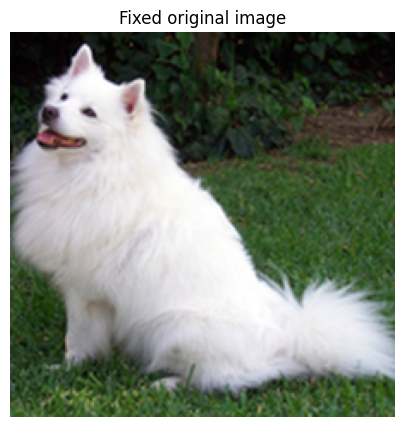

In [5]:
if not INPUT_IMAGE_PATH.is_file():
    raise FileNotFoundError(
        f"Input image not found: {INPUT_IMAGE_PATH}. "
        "Change INPUT_IMAGE_PATH in the parameter cell."
    )

original_image = Image.open(INPUT_IMAGE_PATH).convert("RGB")
original_image = ImageOps.fit(
    original_image,
    (IMAGE_SIZE, IMAGE_SIZE),
    method=Image.Resampling.LANCZOS,
)

print("Original image path:", INPUT_IMAGE_PATH)
print("Original image size:", original_image.size)

plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.title("Fixed original image")
plt.axis("off")
plt.show()

## 6. Load and freeze pretrained ResNet18

The model is a fixed feature judge. Gradients can travel backward through its operations to the generated image, but no model weight is updated.

In [6]:
model = resnet18(weights=ResNet18_Weights.DEFAULT).to(device)
model.eval()

for model_parameter in model.parameters():
    model_parameter.requires_grad_(False)

print("Model parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("Trainable model parameters:", sum(
    p.numel() for p in model.parameters() if p.requires_grad
))

Model parameters: 11,689,512
Trainable model parameters: 0


## 7. Resolve the layer whose features will be amplified

A middle/deep ResNet layer can represent textures and object parts. Caricature compares the layer's complete activation tensor rather than selecting one channel.

In [7]:
modules_by_name = dict(model.named_modules())
if TARGET_LAYER_NAME not in modules_by_name:
    raise KeyError(f"Unknown model layer: {TARGET_LAYER_NAME}")

target_layer = modules_by_name[TARGET_LAYER_NAME]
print("Target layer name:", TARGET_LAYER_NAME)
print("Target layer object:", target_layer)

Target layer name: layer3.1.conv2
Target layer object: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


## 8. Create the DreamLens controller

In [8]:
visualizer = FeatureVisualizer(
    model=model,
    device=device,
    normalize=True,
    quiet=False,
)

print("Visualizer device:", visualizer.device)

Visualizer device: cpu


## 9. Build the paired-transform configuration

During each iteration, the same sampled resize, rotation, and translation is applied to the original and generated images. This keeps their spatial feature maps aligned.

In [9]:
transform_config = TransformConfig(
    rotate_degrees=ROTATE_DEGREES,
    scale_min=SCALE_MIN,
    scale_max=SCALE_MAX,
    translate_x=TRANSLATE_X,
    translate_y=TRANSLATE_Y,
)

print(transform_config)

TransformConfig(rotate_degrees=15, scale_min=0.5, scale_max=1.2, translate_x=0.1, translate_y=0.1, transforms=None)


## 10. Build the amplification configuration

`AmplifyConfig.reference()` selects a generated image backed by random Fourier coefficients. `replace()` exposes the remaining dataclass settings so this notebook keeps every important parameter editable.

In [10]:
amplify_config = AmplifyConfig.reference(
    steps=CARICATURE_STEPS,
    lr=LEARNING_RATE,
)

amplify_config = replace(
    amplify_config,
    weight_decay=WEIGHT_DECAY,
    grad_clip=GRAD_CLIP,
    target_mode=TARGET_MODE,
    transform=transform_config,
)

print(amplify_config)

AmplifyConfig(steps=200, lr=0.009, weight_decay=0.001, grad_clip=1.0, transform=TransformConfig(rotate_degrees=15, scale_min=0.5, scale_max=1.2, translate_x=0.1, translate_y=0.1, transforms=None), preprocess=None, optimizer_cls=None, start='noise', target_mode='paired', preserve_weight=0.0, variation_weight=0.0, noise_std=0.01, fft=True, decorrelate=True, frequency_decay=1.0, raw_scale=0.25, fft_norm=None, parameterization='reference')


## 11. Understand the two paths before running

```text
ORIGINAL PATH — fixed
original RGB → normalize → paired transform → frozen model → target activations T

GENERATED PATH — trainable
Fourier parameters → frequency scaling → inverse FFT → RGB → normalize
→ same paired transform → frozen model → current activations C

compare C with T → negative amplification loss → backward → update Fourier parameters
```

The original image is not converted into Fourier parameters. Fourier is used only to construct the generated image.

## 12. Run `caricature()`

The dedicated render seed is reset immediately before optimization so model creation cannot consume random numbers intended for Fourier initialization.

In [11]:
random.seed(RENDER_SEED)
np.random.seed(RENDER_SEED)
torch.manual_seed(RENDER_SEED)

result = visualizer.visualize(
    method="caricature",
    image=original_image,
    layers=[target_layer],
    power=POWER,
    config=amplify_config,
)

assert isinstance(result, OptimizationResult)
print("Completed steps:", len(result.losses))
print("Final transformed-view loss:", result.losses[-1])
print("Final transformed-view amplification score:", -result.losses[-1])

step 1 reference_amplify_loss -43964.203125
step 100 reference_amplify_loss -1943622.5
step 200 reference_amplify_loss -2789612.25
Completed steps: 200
Final transformed-view loss: -2789612.25
Final transformed-view amplification score: 2789612.25


## 13. Evaluate the final image without random transforms

We capture both complete layer tensors and report three easier-to-understand measurements:

- true cosine similarity: whether the two feature tensors point in the same direction;
- norm ratio: generated feature magnitude divided by original feature magnitude;
- target projection: how strongly generated features project onto the original direction.

In [12]:
generated_features = visualizer.capture_layers(
    layers=[target_layer],
    input_tensor=result.as_nchw(),
    first_batch=False,
)[0]

original_features = visualizer.capture_layers(
    layers=[target_layer],
    input_tensor=original_image,
    first_batch=False,
)[0]

generated_flat = generated_features.flatten()
original_flat = original_features.flatten()

clean_cosine_similarity = F.cosine_similarity(
    generated_flat,
    original_flat,
    dim=0,
)
generated_to_original_norm_ratio = (
    torch.linalg.vector_norm(generated_flat)
    / torch.linalg.vector_norm(original_flat).clamp_min(1e-6)
)
clean_dot_product = torch.sum(generated_flat * original_flat)
clean_target_projection = (
    clean_dot_product
    / torch.linalg.vector_norm(original_flat).clamp_min(1e-6)
)

print("Feature tensor shape:", tuple(generated_features.shape))
print("Clean cosine similarity:", clean_cosine_similarity.item())
print("Generated/original norm ratio:", generated_to_original_norm_ratio.item())
print("Clean target projection:", clean_target_projection.item())

Feature tensor shape: (1, 256, 14, 14)
Clean cosine similarity: 0.7660840749740601
Generated/original norm ratio: 4.01719856262207
Clean target projection: 191.09706115722656


## 14. Display original and caricature side by side

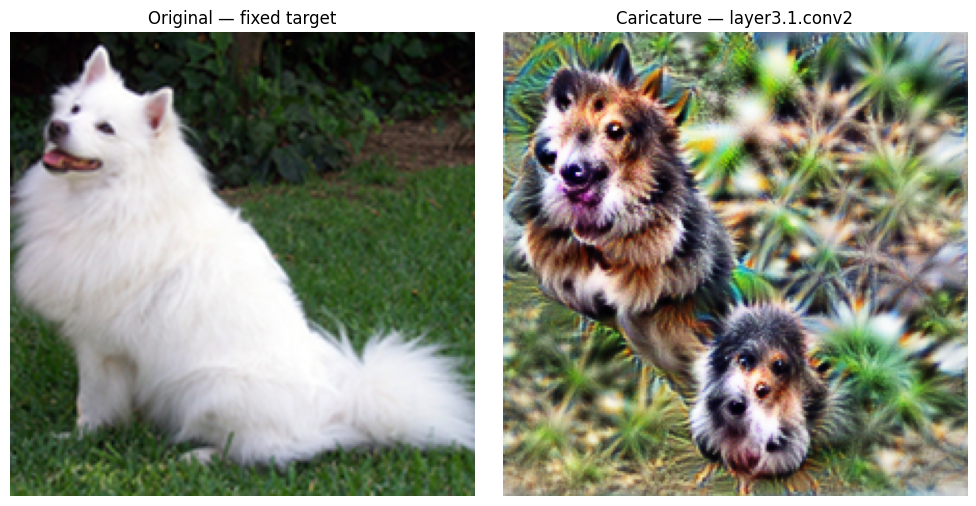

In [13]:
generated_hwc = result.as_hwc().numpy()

figure, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title("Original — fixed target")
axes[0].axis("off")

axes[1].imshow(np.clip(generated_hwc, 0.0, 1.0))
axes[1].set_title(f"Caricature — {TARGET_LAYER_NAME}")
axes[1].axis("off")

figure.tight_layout()
plt.show()

## 15. Plot the amplification history

The native amplification values can be very large, so a logarithmic y-axis makes progress easier to inspect. Random paired transforms can make individual steps fluctuate.

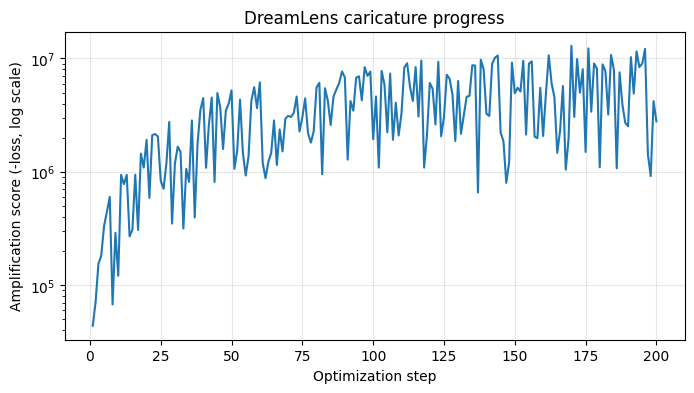

In [14]:
amplification_history = -np.asarray(result.losses, dtype=np.float64)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(amplification_history) + 1), amplification_history)
plt.yscale("log")
plt.xlabel("Optimization step")
plt.ylabel("Amplification score (-loss, log scale)")
plt.title("DreamLens caricature progress")
plt.grid(alpha=0.3)
plt.show()

## 16. Save the visible RGB caricature

In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = OUTPUT_DIR / OUTPUT_FILENAME
result.save(output_path)
print("Saved:", output_path)

Saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/learning_outputs/dreamlens_caricature_notebook/dog_layer3_caricature.png


## 17. Inspect the small public API wrapper

`caricature()` is a convenience wrapper: it forwards the original image, layers, and `power` to the more general `amplify()` workflow.

In [16]:
import inspect

print(inspect.getsource(FeatureVisualizer.caricature))

    def caricature(
        self,
        image,
        layers,
        power=1.2,
        config=None,
        image_parameter=None,
    ):
        """Amplify an input image's layer activations into a caricature."""

        config = AmplifyConfig.reference() if config is None else config
        return self.amplify(
            image=image,
            layers=layers,
            strength=power,
            config=config,
            image_parameter=image_parameter,
        )



## 18. Inspect where inverse FFT is used

This private helper is shown only for learning. Normal application code should use the public API. `irfft2` reconstructs spatial channels before color mixing, sigmoid, normalization, and the model.

In [17]:
import dreamlens.image_parameters as image_parameters_module

print(inspect.getsource(image_parameters_module._reference_fft_to_rgb))

def _reference_fft_to_rgb(image_parameter, height, width, device=None):
    scale = _reference_fft_scale(height, width, device=device).to(
        image_parameter.device
    )
    if width % 2 == 1:
        shaped = image_parameter.reshape(1, 3, height, (width + 1) // 2, 2)
    else:
        shaped = image_parameter.reshape(1, 3, height, width // 2, 2)
    complex_spectrum = torch.complex(shaped[..., 0], shaped[..., 1])
    scaled = scale * complex_spectrum
    return torch.fft.irfft2(scaled, s=(height, width), norm="ortho")



## What to edit first

1. Replace `INPUT_IMAGE_PATH` with one of your images.
2. Compare `POWER=1.05`, `1.15`, and `1.25`. Larger is more aggressive, not automatically better.
3. Compare `CARICATURE_STEPS=45`, `100`, and the tuned `200`.
4. Try `TARGET_LAYER_NAME='layer2.1.conv2'` for more texture or `'layer4.1.conv2'` for deeper, more abstract structure.
5. Reduce transform ranges if the optimization is too difficult, but remember that weaker transforms can create less robust patterns.

The complete flow to remember is:

```text
original image → selected layer → fixed target activations
generated Fourier parameters → inverse FFT → RGB → selected layer → current activations
current vs target → amplification loss → backward → update generated Fourier parameters
```